# 05 · The next-week outlook

Will each community area come in **above or below its normal** next week? This is the project's
forecasting model (`src/outlook/`, run nightly by notebook `08`). The question is deliberately "vs. normal
for this time of year", not "vs. last week": most week-to-week change is noise and season, while "is this
week going to be unusually busy here?" is something a resident can act on.

This notebook builds the pieces up one at a time (the baseline, the features, the backtest), then runs
the whole pipeline, reads its scores and charts, and finally adds a new feature as a challenger.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # run from the repo root or tutorials/
sys.path[:0] = [str(ROOT), str(ROOT / "tutorials")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _data
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#898781"])})
pd.set_option("display.width", 160, "display.max_columns", 30)
print("data from:", _data.source())

from datetime import date, timedelta

from IPython.display import Markdown, display

from src import outlook
from src.community_areas import AREA_NAMES
from src.outlook import features, report, specs

area_daily = _data.crime_daily_by_area()
obs = _data.weather_observed()
forecasts = _data.weather_forecasts()
last_full = _data.last_full_day(area_daily.groupby("day")["n"].sum().reset_index())
run_date = last_full + timedelta(days=9)        # as if run on the day this data would be the newest in the feed
print(f"crime through {last_full}; {len(obs):,} days of observed weather; {len(forecasts):,} archived forecast rows")

data from: local exports


crime through 2026-09-11; 11,226 days of observed weather; 28,500 archived forecast rows


## The baseline: a seasonal bar

"Normal" for a week is the **seasonal bar**: the trailing-year daily rate × a daily seasonal factor. The
factor is the median, over the same weekday 1-5 years back (±1 week, so 15 values), of that day's count
divided by its own trailing-year rate. It carries the weekly cycle and the annual cycle at once, and one
odd year or a holiday in the references barely moves it.

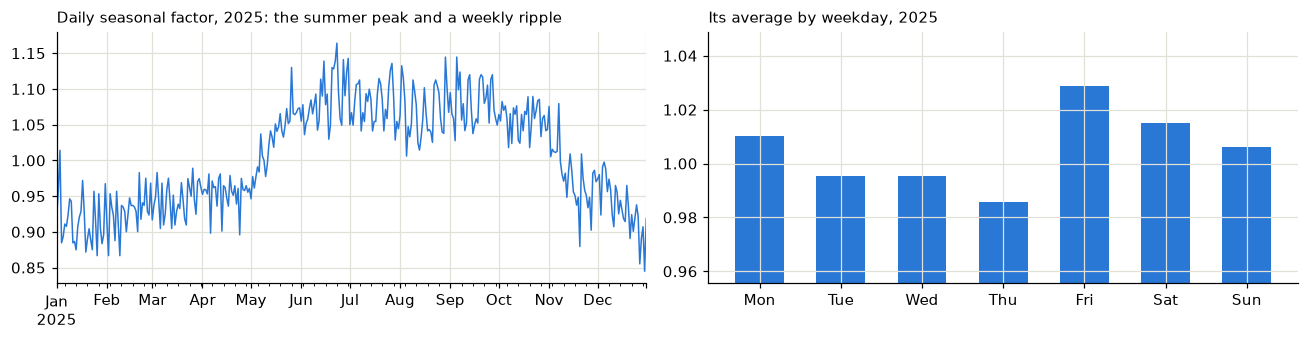

{'Mon': 1.01, 'Tue': 0.995, 'Wed': 0.995, 'Thu': 0.986, 'Fri': 1.029, 'Sat': 1.015, 'Sun': 1.006}


In [2]:
grid, wide, n_real = features.day_grid(area_daily, last_full)
city = wide.sum(axis=1).to_numpy()
season = features.daily_season(city)
s = pd.Series(season, index=grid)[: pd.Timestamp(last_full)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
s["2025-01-01":"2025-12-31"].plot(ax=axes[0], lw=1)
axes[0].set_title("Daily seasonal factor, 2025: the summer peak and a weekly ripple", loc="left", fontsize=10)
by_weekday = s["2025-01-01":"2025-12-31"].groupby(s["2025-01-01":"2025-12-31"].index.day_name().str[:3]).mean()
by_weekday = by_weekday.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].bar(by_weekday.index, by_weekday.to_numpy(), width=0.6)
axes[1].set_ylim(by_weekday.min() - 0.03, by_weekday.max() + 0.02)
axes[1].set_title("Its average by weekday, 2025", loc="left", fontsize=10)
plt.tight_layout(); plt.show()
print(by_weekday.round(3).to_dict())

## The reporting lag, built in

The live crime feed's newest complete day is about 9 days back. A forecast made on a Monday can't see
last week, so every feature at cutoff *c* uses only crime from before *c* − 8 days
(`specs.REPORT_LAG_DAYS`). Training respects it too: a fold may only learn from weeks whose outcome was
already in the feed at its first test cutoff (`evaluation.train_last_for`, 3 weeks back).
`tests/test_outlook_model.py` rebuilds the features from data truncated at the lag and requires them to
match.

Each cutoff Monday becomes one citywide row. The features come in **groups**
(`specs.FEATURE_GROUPS`): each group enters the model together and gets one "driver" in the output.

In [3]:
cutoff = date(2025, 6, 30)            # the week containing the Fourth of July
row = features.city_rows(grid, wide, n_real, obs, forecasts, cutoff, cutoff).iloc[0]
for name, g in specs.FEATURE_GROUPS.items():
    shown = {c: round(float(row[c]), 3) for c in g.columns if not (c.startswith("hol_") and row[c] == 0)}
    print(f"{name:9s} {shown}")
    print(f"{'':9s} {g.description}")
print(f"\ntarget y = {row['y']:,.0f} crimes; bar = {row['bar']:,.0f}; the forecast weather used for this week: "
      f"{row['fc_t_anom']:+.1f} °C vs normal")

momentum  {'dep_7d': -0.09, 'dep_28d': -0.072, 'hol_in_recent_7d': 1.0}
          The city's last 7 and 28 known days against their own seasonal bar, and holidays in the last 7 (which depress them).
calendar  {'hol_independence_day': 1.0, 'month_start': 1.0}
          A flag per holiday in the target week, and whether it includes the 1st of a month.
weather   {'t_anom': 4.066, 'p_anom_cm': -2.083, 't_anom_recent_7d': 1.837, 'snow_recent_7d': 0.0}
          The target week's temperature and rain against normal (observed in training, forecast when forecasting), and the last 7 known days' temperature against normal and snowfall, so a lull the weather caused isn't carried forward as a trend.

target y = 5,385 crimes; bar = 5,174; the forecast weather used for this week: +3.7 °C vs normal


- **momentum**: how far the last 7 and 28 *known* days ran from their own seasonal bar (log ratios), plus
  holidays in the last 7, which depress them.
- **calendar**: a flag per holiday in the target week, and whether it includes the 1st of a month
  ("sometime this month" records are stamped on the 1st).
- **weather**: the target week's temperature and rain against normal. Training uses what was observed;
  backtest and live weeks use the forecast issued the day before the week (`at_forecast_time`), from
  Open-Meteo's archive of past forecasts. So the backtest scores the model on forecasts that existed then,
  not on the weather that happened.

## The model

- **Citywide**: the bar × a Poisson GLM on those features (fit as y/bar with weight bar, which is the same
  as a log-bar offset; scikit-learn has no offset argument).
- **Per area**: the area's own bar × the citywide multiplier × a one-feature local lean (the area's last
  28 known days against its trailing year). The lean is trained with each week's expected counts pinned
  to the actual citywide total, so it only learns who runs hot or cold *relative to the rest of the city*.
- **Calls**: P(next week > normal) from a negative binomial around the forecast, its dispersion fit on
  earlier folds' misses only. Up at P ≥ 0.65, down at P ≤ 0.35.

`outlook.run` does the whole thing: it backtests every model in `specs.CITY_MODELS` and `specs.AREA_MODELS`
on quarterly walk-forward folds from 2022, then forecasts the live week with the champions.

In [4]:
out = outlook.run(area_daily, obs, forecasts, last_full, run_date)
display(Markdown(report.model_card(out)))

## Next-week outlook: week of 2026-09-14

Crime data through 2026-09-11. Citywide forecast **-8.2% vs. normal** (momentum -3.0%, weather -5.2%, calendar +0.0%). Calls: 0 up, 62 down, 15 unclear.

### Backtest: 244 weeks, 2022-01-03 to 2026-08-31

- Citywide: deviance skill +63.9% over the seasonal bar; mean weekly error 6.0% -> 3.8%.
- Areas: calls on 24% of 17,787 area-weeks, right 75% of the time (95% CI 71%-78%) against a 48% base rate; Brier skill +9.3% over climatology.

### Leaderboard

| Level | Model | Features | Skill | Brier skill | Called | Right | AUC |
|---|---|---|---|---|---|---|---|
| city | seasonal_bar | (none) | +0.0% |  |  |  |  |
| city | momentum | momentum | +43.1% |  |  |  |  |
| city | momentum_calendar | momentum, calendar | +45.8% |  |  |  |  |
| city | **full** (champion) | momentum, calendar, weather | +63.9% |  |  |  |  |
| area | normal | (none) | +0.0% | +1.2% | 0% |  | 0.498 |
| area | citywide_only | (none) | +11.6% | +7.7% | 19% | 74% | 0.646 |
| area | **momentum_lean** (champion) | c_accel_28d | +14.0% | +9.3% | 24% | 75% | 0.664 |

Skill is the share of the reference's Poisson deviance removed: the seasonal bar for city models, each area's normal for area models. Calls are up at P(above normal) >= 0.65 and down at <= 0.35.

## Reading the leaderboard

Every row is scored on the same test weeks, so the rows are an **ablation**: each one adds a piece to the
one above it. Deviance skill is the share of the reference's Poisson deviance (its miss) the model removes:
the seasonal bar for city models, each area's normal for area models.

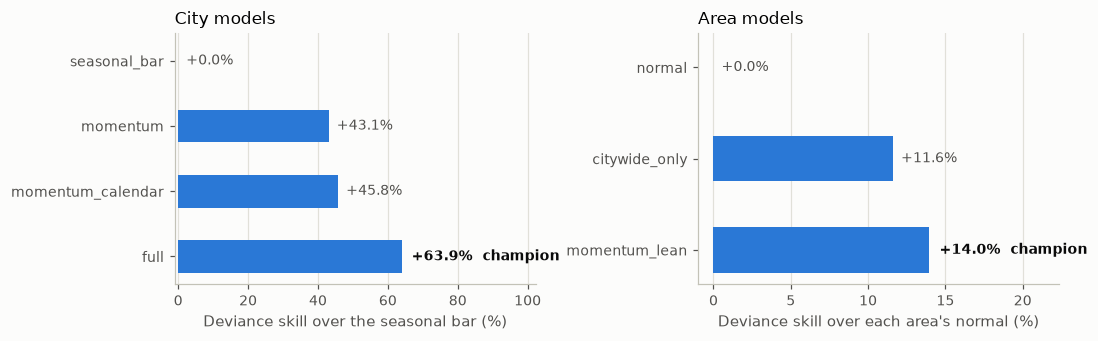

In [5]:
report.plot_leaderboard(out["leaderboard"])
plt.tight_layout(); plt.show()

- Momentum is the biggest single piece: part of a hot or cold run carries into the next week (and the
  trailing-year bar lags real multi-month trends).
- Holidays add a little overall, though individual weeks move a lot.
- The **weather forecast** adds the most after momentum. The research showed the 1-7 day forecast captures
  nearly everything perfect knowledge of the weather would.
- At the area level, most of the skill is the citywide call (`citywide_only`); the local lean adds a bit
  more skill and, more usefully, more confident calls at the same accuracy.

Here is the citywide forecast against what happened, for the last two years of the backtest:

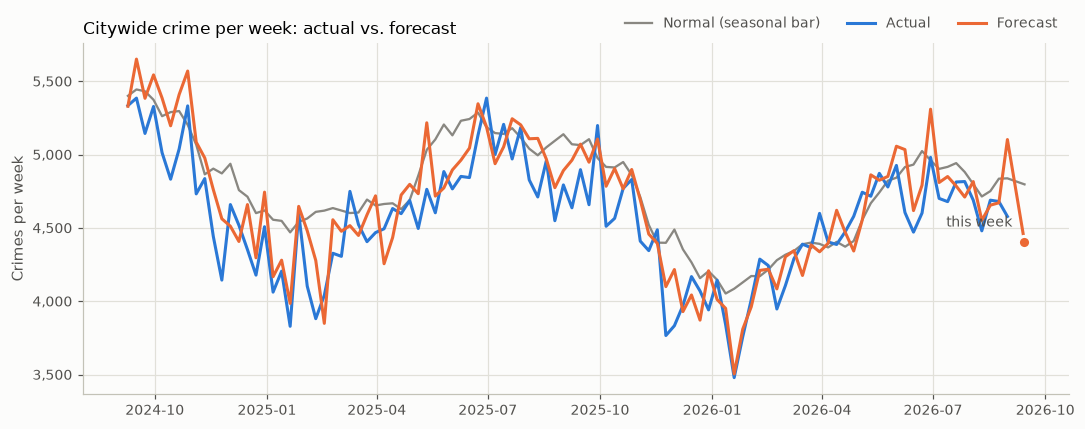

In [6]:
report.plot_backtest(out["city_weeks"])
plt.tight_layout(); plt.show()

## Are the probabilities honest?

A call is only as good as its probability. A reliability diagram bins the backtest's P(above normal) and
checks how often areas really came in above normal: a calibrated model sits on the diagonal.

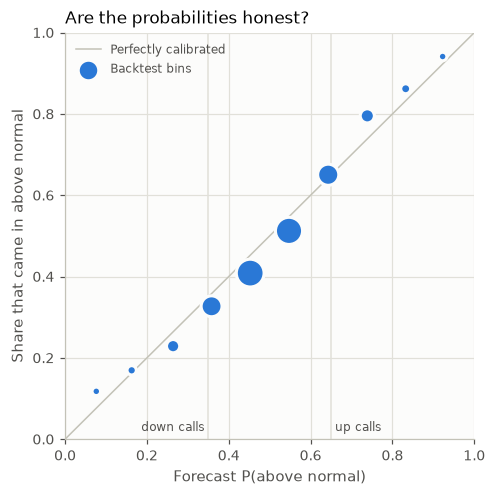

,bin_lo,bin_hi,mean_p,observed,n
0,0.0,0.1,0.076,0.118,17
1,0.1,0.2,0.163,0.169,124
2,0.2,0.3,0.264,0.229,778
3,0.3,0.4,0.358,0.327,2723
4,0.4,0.5,0.452,0.408,5210
5,0.5,0.6,0.547,0.512,4954
6,0.6,0.7,0.643,0.650,2792
7,0.7,0.8,0.739,0.795,962
8,0.8,0.9,0.832,0.862,210
9,0.9,1.0,0.923,0.941,17


In [7]:
fig, ax = plt.subplots(figsize=(4.8, 4.8))
report.plot_calibration(out["calibration"], ax=ax)
plt.show()
out["calibration"].round(3)

## This week

The live week's citywide drivers, and every area's probability of coming in above normal. Most of a week's
swing is citywide (weather, the city's recent run, holidays), so neighboring areas often get the same call.
The app keeps the citywide and local parts apart for exactly that reason: a "below normal" call driven by a
cool week says nothing good about the area itself.

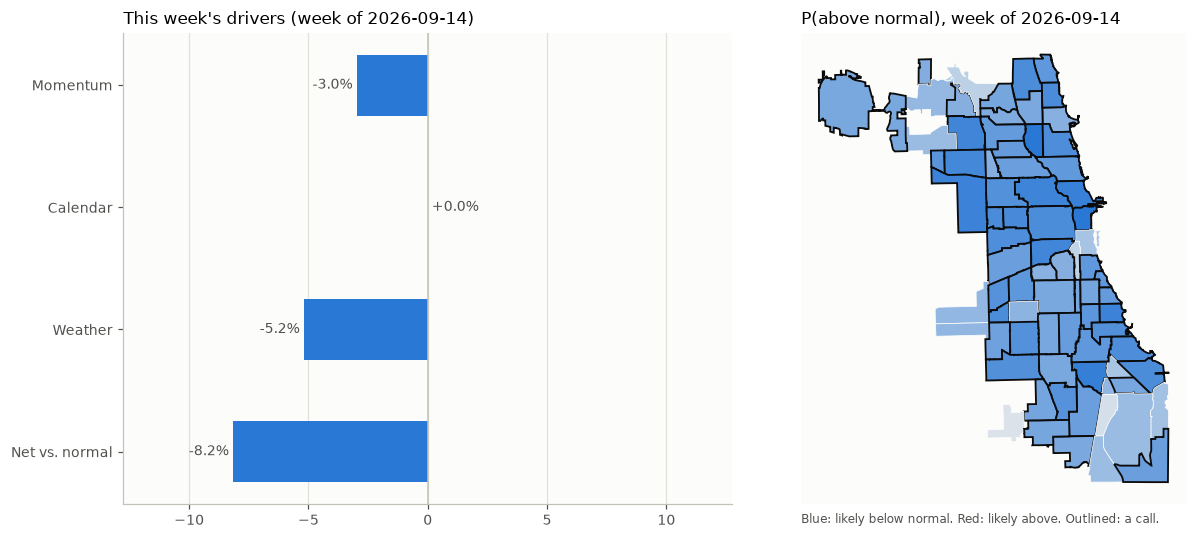

,area,normal,forecast,p_above,call,pct_citywide,pct_local
18861,Mount Greenwood,10.69,10.44,0.47,unclear,-0.08,0.06
18837,Pullman,22.70,22.22,0.46,unclear,-0.08,0.07
18821,Armour Square,25.90,24.74,0.43,unclear,-0.08,0.04
18831,Chatham,105.48,95.11,0.22,down,-0.08,-0.02
18819,Loop,168.32,152.31,0.20,down,-0.08,-0.01
18792,North Center,27.27,22.69,0.18,down,-0.08,-0.09


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1]})
report.plot_drivers(out["city_weeks"], ax=axes[0])
report.plot_area_map(out["area_weeks"], ax=axes[1])
plt.tight_layout(); plt.show()

live = out["area_weeks"][out["area_weeks"]["is_live"]].assign(area=lambda d: d["community_area"].map(AREA_NAMES))
cols = ["area", "normal", "forecast", "p_above", "call", "pct_citywide", "pct_local"]
live.sort_values("p_above", ascending=False)[cols].round(2).iloc[[0, 1, 2, -3, -2, -1]]

## What moves a week's crime

The live citywide model's coefficients, as % changes, in the units a person reads (°F, inches): the
same numbers the Insights page and the agent quote.

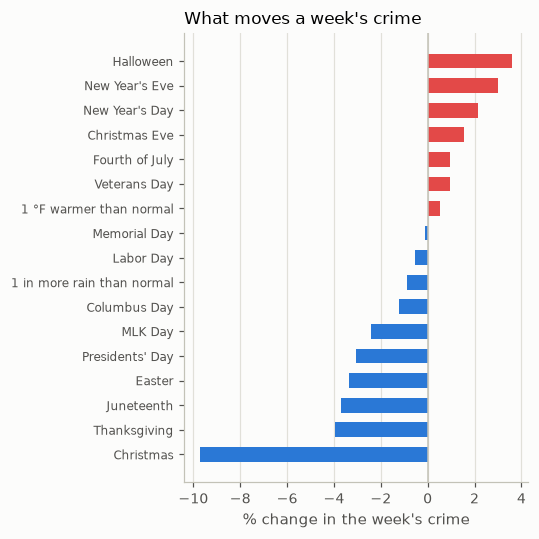

In [9]:
report.plot_effects(out["coefficients"])
plt.tight_layout(); plt.show()

## Extending it: try a new feature

This is how the model gets better. The weather group's **recent snowfall** feature was added exactly
this way: tested as a challenger, it beat the champion in every test year, so it shipped (`docs/modeling.md`).

Here, try a folk hypothesis instead: *crime rises around the full moon*. Testing it takes three steps, none
of which touch the shipped model:

1. **Compute the column** in a builder (`features.CITY_BUILDERS`). It may only use what's known at the
   cutoff. The moon is known years ahead, so the target week's own full-moon nights are fair game.
2. **Register a feature group** for it (`specs.FEATURE_GROUPS`).
3. **Pass a challenger spec** to `outlook.run`; the leaderboard scores it on the same weeks as the champion.

In [10]:
SYNODIC = 29.530588853                       # days from new moon to new moon
NEW_MOON = pd.Timestamp("2000-01-06 18:14")    # a known new moon

def full_moon_nights(first_day, days=7):
    """Nights in the week with the moon at least 95% lit."""
    t = pd.date_range(pd.Timestamp(first_day) + pd.Timedelta(hours=22), periods=days, freq="D")
    phase = ((t - NEW_MOON) / pd.Timedelta(days=1)) % SYNODIC
    return int(((1 - np.cos(2 * np.pi * phase / SYNODIC)) / 2 >= 0.95).sum())

def moon_columns(ctx):
    return pd.DataFrame({"cutoff": ctx.cutoffs, "full_moon_nights": [full_moon_nights(c) for c in ctx.cutoffs]})

features.CITY_BUILDERS.append(moon_columns)
specs.FEATURE_GROUPS["moon"] = specs.FeatureGroup("moon", ("full_moon_nights",), description="nights the moon is 95%+ lit")
try:
    challenger = {"full_plus_moon": outlook.CityModelSpec("full_plus_moon", ("momentum", "calendar", "weather", "moon"))}
    models = {**outlook.CITY_MODELS, **challenger}
    out2 = outlook.run(area_daily, obs, forecasts, last_full, run_date, city_models=models)
    # served as if it were the champion, to get its week-by-week backtest and its fitted effect
    out3 = outlook.run(area_daily, obs, forecasts, last_full, run_date, city_models=models, champion_city="full_plus_moon")
finally:                         # leave the shipped registries as they were
    features.CITY_BUILDERS.remove(moon_columns)
    del specs.FEATURE_GROUPS["moon"]

effect = out3["coefficients"].set_index("feature").at["full_moon_nights", "pct_per_unit"]
print(f"fitted effect: {effect:+.2f}% crime per full-moon night in the week")
lb = out2["leaderboard"]
lb[lb["level"] == "city"][["model", "champion", "features", "skill", "weekly_error"]].round(4)

fitted effect: -0.01% crime per full-moon night in the week


,model,champion,features,skill,weekly_error
0,seasonal_bar,False,(none),0.0000,0.0605
1,momentum,False,momentum,0.4307,0.0450
2,momentum_calendar,False,"momentum, calendar",0.4577,0.0449
3,full,True,"momentum, calendar, weather",0.6394,0.0379
4,full_plus_moon,False,"momentum, calendar, weather, moon",0.6391,0.0379


A total is one number, and a small difference in it can be luck. Before promoting anything, check that it
holds up year by year: the same deviance skill, per test year, for both models.

In [11]:
def yearly_skill(city_weeks):
    bt = city_weeks[~city_weeks["is_live"]].assign(year=lambda d: pd.to_datetime(d["cutoff"]).dt.year)
    return bt.groupby("year").apply(lambda g: 1 - outlook.deviance(g["y"].to_numpy(), g["forecast"].to_numpy())
                                    / outlook.deviance(g["y"].to_numpy(), g["bar_calibrated"].to_numpy()),
                                    include_groups=False)

pd.DataFrame({"full (champion)": yearly_skill(out["city_weeks"]),
              "full_plus_moon": yearly_skill(out3["city_weeks"])}).assign(
    difference=lambda d: d["full_plus_moon"] - d["full (champion)"]).round(3)

,full (champion),full_plus_moon,difference
year,,,
2022,0.811,0.811,-0.000
2023,0.526,0.525,-0.001
2024,0.352,0.350,-0.001
2025,0.575,0.576,0.000
2026,0.381,0.379,-0.002


The moon does nothing. Its fitted effect is about zero, and the challenger never beats the champion in
any year; the tiny losses are the price of one more noisy feature. Compare that with snow, which won
every year, and that's the difference between a hunch and a feature.

The rule is mechanical: if a challenger beats the champion clearly and consistently (by more than the
year-to-year wobble), move its builder and group into `features.py` and `specs.py` for real (or add its
columns to an existing group, as snow joined `weather`), point `specs.CHAMPION_CITY` at it if it's a new
spec, rerun the tests, and the next nightly run serves it. If not, the leaderboard has just saved you from
shipping a feature on a hunch.

Two more things make the model easy to keep an eye on:
- Notebook `08` writes `outlook_leaderboard` and `outlook_calibration` to Unity Catalog every night, and
  logs each run's settings, scores, model card and dashboard to MLflow, so drift shows up as a trend.
- `report.dashboard(out)` puts every chart above in one figure (it's the image in `docs/modeling.md`).

Next: [06 · Events look-ahead](06_events_lookahead.ipynb).